In [2]:
import sys
from pathlib import Path
import numpy as np
from scipy import stats
from pandas.api import types as ptypes


def add_project_root_with_libs(marker_dirname="create_db"):
    p = Path.cwd()
    for parent in [p] + list(p.parents):
        if (parent / marker_dirname).is_dir():
            sys.path.insert(0, str(parent))  
            return parent
    raise FileNotFoundError(f"Could not find a parent dir containing {marker_dirname}")

project_root = add_project_root_with_libs("create_db")


from sqlalchemy import (
    create_engine,
    inspect,
    text,
    select,
    cast, Float, func,
    and_
)
from sqlalchemy.orm import sessionmaker,relationship 


from create_db import config_local
from create_db.data_classes import Player, PlayerStat, MVPCandidate, MVPWinner, AdvancedStat, TeamPerformance, Roster, SeasonStat, Team
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pandas as pd

DB_USER, DB_PASSWORD, DB_HOST, DB_PORT, DB_NAME = (
    config_local.DB_USER,
    config_local.DB_PASSWORD,
    config_local.DB_HOST,
    config_local.DB_PORT,
    config_local.DB_NAME,
)


engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True,
)
SessionLocal = sessionmaker(bind=engine)

session = SessionLocal()


team_id = 'DAL'
season_start = 2019
season_end = 2025

In [3]:
for model in (Player, PlayerStat, MVPCandidate, MVPWinner, AdvancedStat, TeamPerformance, Roster, SeasonStat, Team):
    mapper = inspect(model)
    print (model.__tablename__)
    print (mapper.columns.keys())
    print ("relationships:", mapper.relationships.keys() )
    print ("-"*25)


players
['player_id', 'player_name', 'shoots', 'draft_team_name', 'experience', 'nba_debut', 'position_1', 'position_2', 'position_3', 'position_4', 'position_5', 'position_6', 'draft_year', 'height_cm', 'weight_kg', 'age', 'draft_round_pick_rank', 'draft_overall_pick_rank', 'career_points', 'career_total_rebound_pct', 'career_assists_pct', 'career_field_goal_pct', 'career_three_point_pct', 'career_free_throw_pct', 'career_effective_fg_pct', 'career_per', 'career_win_shares']
relationships: ['playerstats', 'mvp_finishes', 'mvp_titles', 'rosters', 'advanced_stats']
-------------------------
player_stats
['season', 'player_id', 'rank', 'age', 'team_id', 'position', 'games_played', 'games_started', 'minutes_played', 'field_goals_made', 'field_goals_attempted', 'field_goal_pct', 'three_pointers_made', 'three_pointers_attempted', 'three_point_pct', 'two_pointers_made', 'two_pointers_attempted', 'two_point_pct', 'effective_fg_pct', 'free_throws_made', 'free_throws_attempted', 'free_throw_pct

<div dir="rtl">

## سناریو

مدیر شما برای اینکه مدیر تیم **دالاس** را بیشتر ضایع کند، در مصاحبه‌ای ادعا می‌کند که:

 **Availability قهرمانی می‌آورد!**

### وظیفه شما
1. نموداری از **راستر این فصل دالاس** و میزان **Availability** آنها در فصل‌های گذشته ارائه دهید.  

</div>


In [4]:
stmt = (
    select(
        Roster.player_id,
        Player.player_name,
        PlayerStat.season,
        PlayerStat.games_played,
        (TeamPerformance.games).label("total_games"),
        (PlayerStat.games_played / TeamPerformance.games).label("availability"),
    )
    .join(PlayerStat,
          and_(
              Roster.player_id == PlayerStat.player_id,
              Roster.team_id == PlayerStat.team_id,
              Roster.season == '2026'
          ))
    .join(Player, Player.player_id == PlayerStat.player_id)
    .join(
        TeamPerformance,
        and_(
            TeamPerformance.team_id == PlayerStat.team_id,
            TeamPerformance.season == PlayerStat.season,
        ),
    )
    .where(Roster.team_id == team_id, PlayerStat.season >= season_start)
    .order_by(Player.player_name, Roster.season)
)


dallas_roster_stats_df = pd.read_sql(stmt, session.get_bind())
dallas_roster_stats_df

,player_id,player_name,season,games_played,total_games,availability
0,willibr03,brandon williams,2024,17,82,0.2073
1,willibr03,brandon williams,2025,33,82,0.4024
2,gaffoda01,daniel gafford,2025,57,82,0.6951
3,exumda01,dante exum,2024,55,82,0.6707
4,exumda01,dante exum,2025,20,82,0.2439
5,livelde01,dereck lively ii,2025,36,82,0.4390
6,livelde01,dereck lively ii,2024,55,82,0.6707
7,poweldw01,dwight powell,2020,40,75,0.5333
8,poweldw01,dwight powell,2021,58,72,0.8056
9,poweldw01,dwight powell,2025,55,82,0.6707


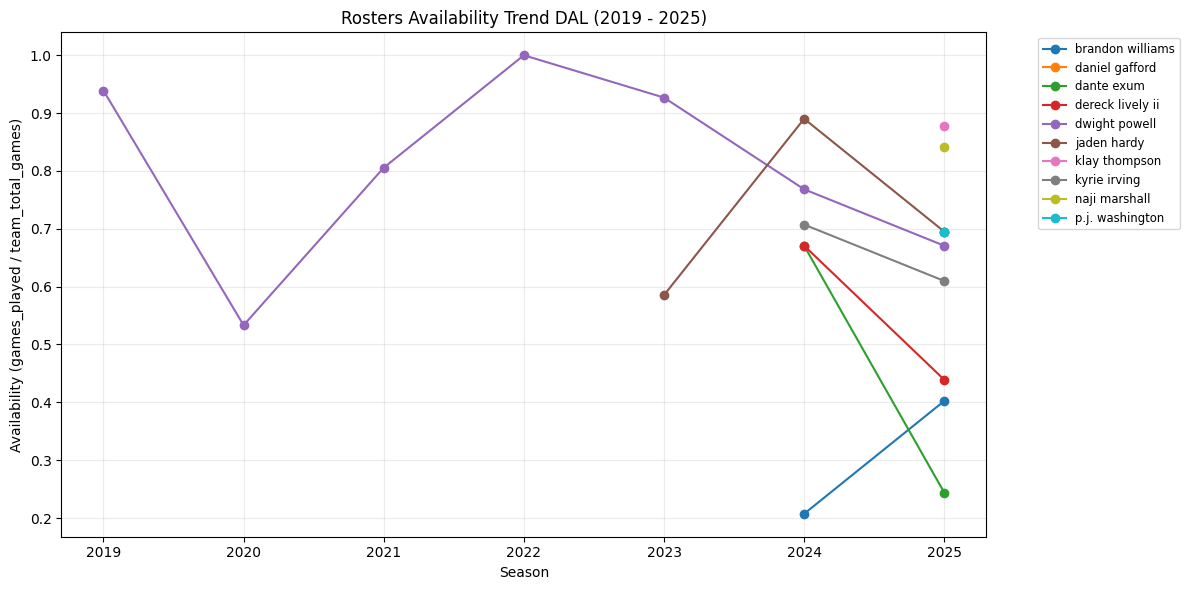

In [5]:

pivot = dallas_roster_stats_df.pivot_table(index="season", columns="player_name", values="availability")
pivot = pivot.sort_index()
plt.figure(figsize=(12, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker='o', label=col)
plt.title(f"Rosters Availability Trend {team_id} ({season_start} - {season_end})")
plt.xlabel("Season")
plt.ylabel("Availability (games_played / team_total_games)")
plt.legend(bbox_to_anchor=(1.05, 1),  fontsize='small')
plt.grid(alpha=0.25)
plt.tight_layout()


<div dir="rtl">

### وظیفه شما

2. از **لیست کاندیدهای MVP** برای چند فصل گذشته استفاده کرده و **Availability آنها در فصل قبل** را به دست آورید.  

</div>

In [6]:
def custom_barplot(data:pd.DataFrame,title_text,subtitle,footnote = "",x_field='season',y_field = 'availability'):
    fig_w, fig_h = 14, 6
    bg_color = "#0b1f23"         
    bar_color = "#e74f6b"        
    highlight_color = "#ffce54"   
    text_color = "white"
    percent_fmt = "{:.0f}%"
    highlight_index = data[data[y_field] == data[y_field].max()].index

    df_clean = None
    df_clean = data.dropna(subset=[y_field]).copy()
    seasons =sorted(df_clean[x_field].unique())
    
    if ptypes.is_numeric_dtype(data[x_field].dtype):
        seasons_x = [f"{season}-{int(str(season)[2:])+1}" for season in sorted(df_clean[x_field].unique())]
    else:
        seasons_x = seasons
    
    
    values = [df_clean[df_clean[x_field] == s][y_field].values[0] * 100 for s in seasons]


    fig = plt.figure(figsize=(fig_w, fig_h), facecolor=bg_color)
    ax = fig.add_axes([0.18, 0.15, 0.78, 0.8]) 
    ax.set_facecolor(bg_color)


    x = np.arange(len(seasons_x))
    width = 0.60

    colors = [highlight_color if i == highlight_index else bar_color for i in range(len(values))]

    bars = ax.bar(x, values, width=width, color=colors, edgecolor="#2a2a2a", linewidth=0.8, zorder=3)

    for i, (b, v) in enumerate(zip(bars, values)):
        ax.text(
            b.get_x() + b.get_width()/2,
            v + 3,   # vertical offset
            percent_fmt.format(v),
            ha="center",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color=text_color if i != highlight_index else "#e74f6b"
        )
        
    ax.set_xticks(x)
    ax.set_xticklabels(seasons_x, fontsize=14, color="#d6e3e3")
    ax.tick_params(axis='x', which='both', pad=10)


    ax.text(-0.02, 1.08, title_text, transform=ax.transAxes,
            fontsize=20, fontweight="bold", color="#ff9fb3", ha="left")
    ax.text(-0.02, 1.02, subtitle, transform=ax.transAxes,
            fontsize=12, color="#d6e3e3", ha="left")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color("#2f4f4f")
    ax.set_yticks([])   

    ymax = 120
    # int(max(data)) + 60
    ax.set_ylim(0, ymax)
    ax.set_yticks([0, 25, 50, 75, 100,120])
    ax.set_yticklabels([])   
    ax.grid(axis='y', color="#154040", linestyle='--', linewidth=0.6, zorder=0)


    hx = x[highlight_index]
    ax.hlines(-2.5, hx - 0.3, hx + 0.3, transform=ax.get_xaxis_transform(), colors="#ff9fb3", linewidth=6, zorder=4)

    ax.text(0.02, -0.12, footnote, transform=ax.transAxes,
            fontsize=12, color="#ffd1d9", bbox=dict(facecolor="#1a2b2b", alpha=0.6, boxstyle="round,pad=0.4"))

    for b in bars:
        b.set_linewidth(0)
        b.set_alpha(0.95)
        
    plt.show()

In [7]:
stmt = (
    select(
        MVPCandidate.year.label('vote_season'),
        MVPCandidate.player_id,
        Player.player_name,
        TeamPerformance.games.label("total_games"),
        PlayerStat.games_played,
        (PlayerStat.games_played / TeamPerformance.games).label(
            "availability_last_season"
        ),
    )
    .join(Player, Player.player_id == MVPCandidate.player_id)
    .join(
        PlayerStat,
        and_(
            MVPCandidate.player_id == PlayerStat.player_id,
            PlayerStat.season == MVPCandidate.year,
        ),
    )
    .join(
        TeamPerformance,
        and_(
            TeamPerformance.team_id == MVPCandidate.team_id,
            TeamPerformance.season == MVPCandidate.year,
        ),
    )
    .where(MVPCandidate.rank <= 5)
    .order_by(MVPCandidate.year, MVPCandidate.rank)
)


mvp_candidate_df = pd.read_sql(stmt, session.get_bind())
mvp_candidate_df

,vote_season,player_id,player_name,total_games,games_played,availability_last_season
0,2019,antetgi01,giannis antetokounmpo,82,72,0.8780
1,2019,hardeja01,james harden,82,78,0.9512
2,2019,georgpa01,paul george,82,77,0.9390
3,2019,jokicni01,nikola jokiä,82,80,0.9756
4,2019,curryst01,stephen curry,82,69,0.8415
5,2020,antetgi01,giannis antetokounmpo,73,63,0.8630
6,2020,jamesle01,lebron james,71,67,0.9437
7,2020,hardeja01,james harden,72,68,0.9444
8,2020,doncilu01,luka donäiä,75,61,0.8133
9,2020,leonaka01,kawhi leonard,72,57,0.7917


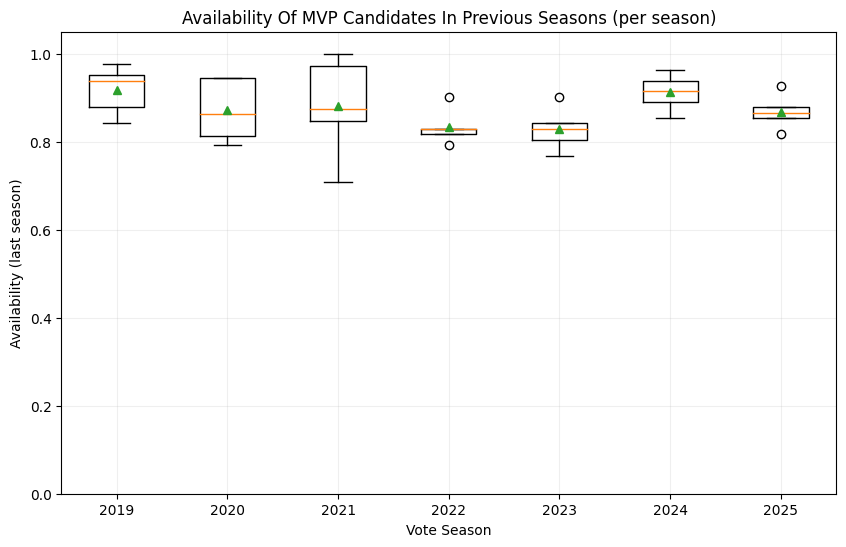


MVP availability stats (last season):
 season  mean_availability  std_availability  n_candidates
   2019            0.91706          0.049616             5
   2020            0.87122          0.063803             5
   2021            0.88054          0.103423             5
   2022            0.83416          0.036644             5
   2023            0.82928          0.044292             5
   2024            0.91218          0.038083             5
   2025            0.86830          0.035656             5


In [189]:
df_mvp_candidate_clean = mvp_candidate_df.dropna(subset=["availability_last_season"]).copy()

seasons = sorted(df_mvp_candidate_clean["vote_season"].unique())
data = [df_mvp_candidate_clean[df_mvp_candidate_clean["vote_season"] == s]["availability_last_season"].values for s in seasons]

plt.figure(figsize=(10,6))
plt.boxplot(data, labels=seasons, showmeans=True)
plt.title("Availability Of MVP Candidates In Previous Seasons (per season)")
plt.xlabel("Vote Season")
plt.ylabel("Availability (last season)")
plt.ylim(0,1.05)
plt.grid(alpha=0.2)
plt.show()

stats = []
for s in seasons:
    arr = df_mvp_candidate_clean[df_mvp_candidate_clean["vote_season"] == s]["availability_last_season"].dropna().values
    if len(arr)>0:
        stats.append((s, np.mean(arr), np.std(arr), len(arr)))
    else:
        stats.append((s, np.nan, np.nan, 0))
stats_df = pd.DataFrame(stats, columns=["season","mean_availability","std_availability","n_candidates"])
print("\nMVP availability stats (last season):")
print(stats_df.to_string(index=False))


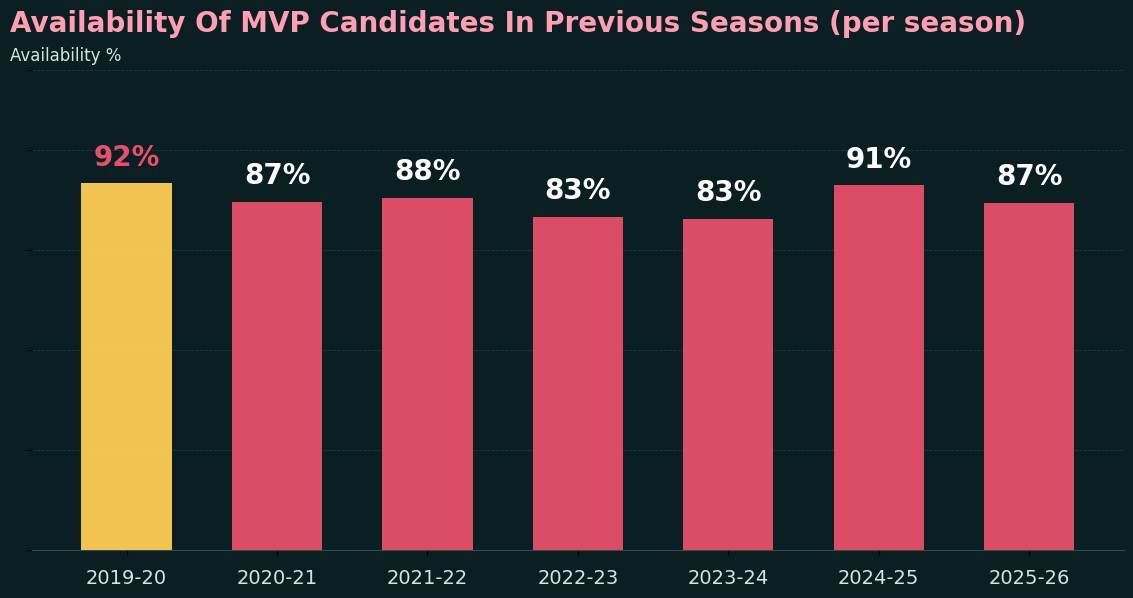

In [8]:
df_mvp_candidate_clean = mvp_candidate_df.dropna(subset=["availability_last_season"]).copy()

seasons = sorted(mvp_candidate_df["vote_season"].unique())
data = df_mvp_candidate_clean.dropna().groupby(['vote_season']).mean('availability_last_season').reset_index()

custom_barplot(data=data,title_text='Availability Of MVP Candidates In Previous Seasons (per season)'
            ,subtitle='Availability %',x_field='vote_season',y_field='availability_last_season')

<div dir="rtl" >

3. لیستی از بازیکنان **قهرمان چند فصل قبل** را نیز استخراج کنید.  

</div>

In [9]:
stmt = (
    select(
        MVPWinner.season,
        MVPWinner.team_id,
        PlayerStat.player_id,
        Player.player_name,
        TeamPerformance.games.label("total_games"),
        PlayerStat.games_played,
        (PlayerStat.games_played / TeamPerformance.games).label("availability"),
    )
    .join(
        PlayerStat,
        and_(
            MVPWinner.player_id == PlayerStat.player_id,
            PlayerStat.season == MVPWinner.season,
        ),
    )
    .join(Player, Player.player_id == MVPWinner.player_id)
    .join(
        TeamPerformance,
        and_(
            TeamPerformance.team_id == MVPWinner.team_id,
            TeamPerformance.season == MVPWinner.season,
        ),
    )
    .order_by(MVPWinner.season, Player.player_name)
)




mvp_df = pd.read_sql(stmt, session.get_bind())
mvp_df

,season,team_id,player_id,player_name,total_games,games_played,availability
0,2019,mil,antetgi01,giannis antetokounmpo,82,72,0.8780
1,2020,mil,antetgi01,giannis antetokounmpo,73,63,0.8630
2,2021,den,jokicni01,nikola jokiä,72,72,1.0000
3,2022,den,jokicni01,nikola jokiä,82,74,0.9024
4,2023,phi,embiijo01,joel embiid,82,66,0.8049
5,2024,den,jokicni01,nikola jokiä,82,79,0.9634
6,2025,okc,gilgesh01,shai gilgeous-alexander,82,76,0.9268


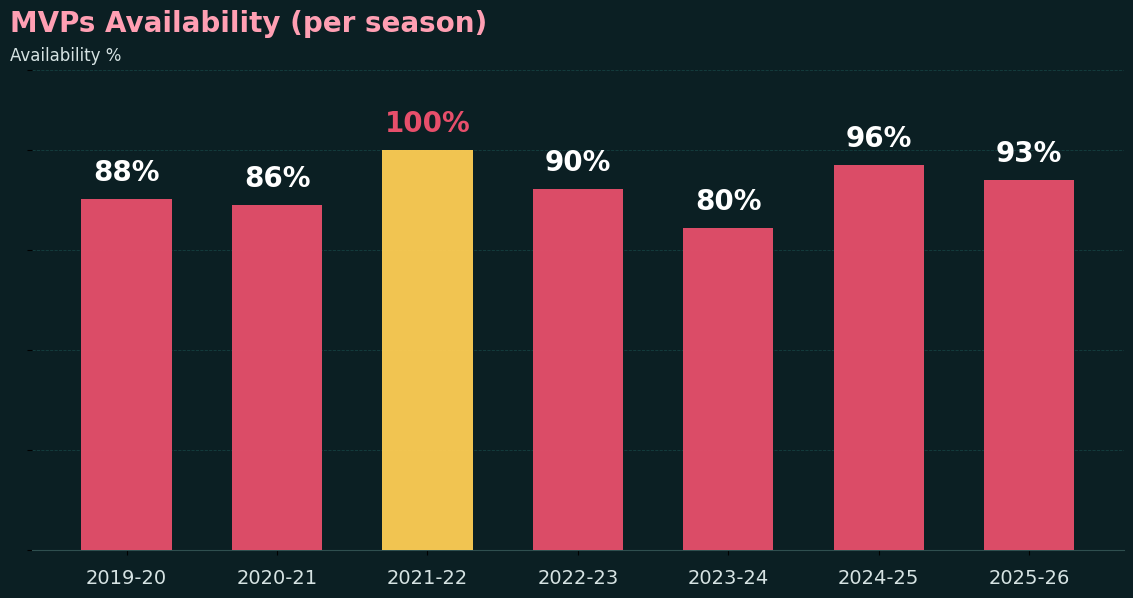

MVPs availability stats:
 season  mean_availability  std_availability  n_players
   2019             0.8780               0.0          1
   2020             0.8630               0.0          1
   2021             1.0000               0.0          1
   2022             0.9024               0.0          1
   2023             0.8049               0.0          1
   2024             0.9634               0.0          1
   2025             0.9268               0.0          1


In [187]:
mvp_df_clean = mvp_df.dropna(subset=["availability"]).copy()
seasons = sorted(mvp_df_clean["season"].unique())
data = mvp_df_clean.dropna().groupby(['season']).mean('availability').reset_index()

custom_barplot(data=data,title_text='MVPs Availability (per season)',
               subtitle='Availability %',x_field='season',y_field='availability')

stats = []
for s in seasons:
    arr = mvp_df_clean[mvp_df_clean["season"] == s]["availability"].dropna().values
    if len(arr)>0:
        stats.append((s, np.mean(arr), np.std(arr), len(arr)))
    else:
        stats.append((s, np.nan, np.nan, 0))
stats_df = pd.DataFrame(stats, columns=["season","mean_availability","std_availability","n_players"])
print("MVPs availability stats:")
print(stats_df.to_string(index=False))



<div dir="rtl" >

4. بررسی کنید که آیا بین Availability این گروه‌ها **تفاوت محسوسی** وجود دارد یا خیر.

</div>

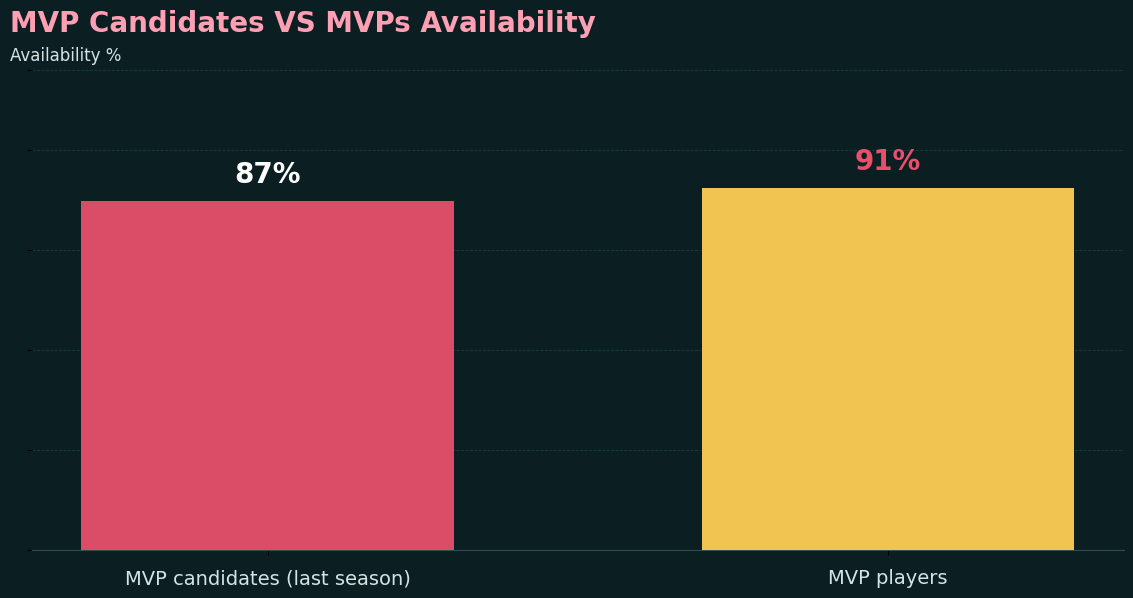


🔎 T-test results:
t-statistic = -1.192, p-value = 0.26484
➡️ نتیجه: تفاوت میانگین‌ها معنی‌دار نیست (شاید اختلاف فقط شانسی باشد).


In [182]:
mvp_condidate_avail = mvp_candidate_df["availability_last_season"].dropna().astype(float)
mvp_winner_avail = mvp_df_clean["availability"].dropna().astype(float)

groups = ["MVP candidates (last season)", "MVP players"]
means = [mvp_condidate_avail.mean(), mvp_winner_avail.mean()]
stds = [mvp_condidate_avail.std(), mvp_winner_avail.std()]

data = pd.DataFrame({
    "x_field":groups,
    "y_field":means
})


    
custom_barplot(data=data,title_text='MVP Candidates VS MVPs Availability'
            ,subtitle='Availability %',x_field='x_field',y_field='y_field')

t_stat, p_val = stats.ttest_ind(mvp_condidate_avail, mvp_winner_avail , equal_var=False)
print("\n🔎 T-test results:")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.5f}")
if p_val < 0.05:
    print("➡️ نتیجه: تفاوت میانگین‌ها معنی‌دار است (Availability این دو گروه متفاوت است).")
else:
    print("➡️ نتیجه: تفاوت میانگین‌ها معنی‌دار نیست (شاید اختلاف فقط شانسی باشد).")